# TipTop - MAVIS 2026 Hands-On - Tutorial A

In this tutorial, we will use MAVIS as a concrete example to explore three
different ways of using TipTop:

### 1 — PREDICT 🔭
**Given a MAVIS configuration, what PSF does TipTop predict?**

Run a baseline simulation, inspect the PSFs across the MCAO field,
and retrieve the main AO performance metrics.

### 2 — EXPLORE 🔎
> **What happens if I change the observing conditions?**

We will use `baseSimulation` + `sim.my_data_map` to vary parameters directly in Python, without rewriting the `.ini` file.

### 3 — SELECT ⭐
**What if several guide-star configurations are possible?**

Use TipTop to compare candidate NGS asterisms based on their predicted
AO performance.

## Requirements

- Python 3.11+
- TipTop v1.5.1 or later
- `astropy`, `matplotlib`, `numpy`
- **MAVIS base INI file** — download [here](https://astro-tiptop-services.github.io/astro-tiptop-services/resources/mavis_2026)
- for the **SELECT** section: a MAVIS configuration containing an `[ASTERISM_SELECTION]` block

This notebook deliberately starts from a validated MAVIS configuration rather than building an AO system from scratch. The aim is to manipulate the quantities that matter for an observing/science question.


## Roadmap

This hands-on is organized around two main TipTop workflows:

| Part | What we will do | TipTop interface | Time |
|---|---|---|---:|
| **PREDICT** | Run a MAVIS simulation and inspect the predicted PSFs and AO performance | `overallSimulation` | ~20 min |
| **EXPLORE** | Modify the configuration and compare repeated simulations | `baseSimulation`, `sim.my_data_map` | ~30 min |
| **Wrap-up** | Review the main TipTop workflows and resources | — | ~5 min |

**If time allows:** a separate **SELECT** notebook introduces NGS asterism
selection with `asterismSelection()`.

## What we will use

During this hands-on, we will use TipTop in several ways:

- run a simulation from an existing MAVIS configuration;
- retrieve PSFs and AO performance metrics;
- examine the PSF at different positions across the MCAO science field;
- access the simulation and its outputs directly in Python;
- modify selected configuration parameters and rerun the simulation;
- compare the resulting PSFs and performance metrics across several cases.

The optional **SELECT** notebook introduces another TipTop workflow:
evaluating and ranking candidate NGS asterisms.

---

## Setup 🧩

We will first run TipTop through its simple high-level interface, then switch to an in-memory simulation object for the exploration.


### A) Imports

In [9]:
from tiptop.tiptop import overallSimulation
from tiptop.tiptopUtils import hdr2map
from p3.aoSystem import FourierUtils

from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os


### B) Define paths and filenames

- `path_in` : folder containing your `.ini` parameter file
- `path_out` : output folder (must exist or be creatable)
- `file_in` : base name (without extension) of the `.ini` file
- `file_out` : prefix for output files

In [ ]:
# %% Path configuration — adapt to your setup
path_in = "./"
path_out = "./TIPTOP_OUT/" 
file_in = "mavis"  # without .ini extension
file_out = "mavis_out" # output prefix

os.makedirs(path_out, exist_ok=True)

print("Input :", os.path.join(path_in, file_in + ".ini"))
print("Output:", os.path.join(path_out, file_out + ".fits"))


---

## 1 — PREDICT 🔭

### What PSF does TipTop predict?

In this section, we will:

1. inspect the science and guide-star geometry defined in `mavis.ini`;
2. run a first MAVIS simulation;
3. retrieve the predicted PSFs and metrics;
4. examine how the PSF varies across the MCAO science field.

### Before running

Have a look at the `sources_science` and `sources_LO`sections in `mavis.ini`.

Source positions are defined using the same convention in the
`[sources_science]`, `[sources_HO]`, and `[sources_LO]` sections.

- `Zenith` gives the angular separation from the pointing direction, in arcsec.
- `Azimuth` gives the position angle around the field, in degrees.
- `Zenith = 0` corresponds to an on-axis source.

**TipTop convention for source positions: [here](http://localhost:3000/astro-tiptop-services/docs/orion/parameterfiles#ZA_schemes)**

How many science directions are defined, and therefore how many PSFs do you expect TipTop to compute?

In [ ]:
from configparser import ConfigParser
from tiptop.tiptopUtils import plot_directions

parser = ConfigParser()
parser.read("./mavis.ini")

plot_directions(parser, ticks_interval=5, science=True, low_order=True, add_legend=True)

### C) Run TipTop simulation

`tiptop.overallSimulation` runs a complete TipTop simulation based on an input parameter file. The function accepts several optional arguments to enable or disable specific features and select desired outputs.

Click [here](https://astro-tiptop-services.github.io/astro-tiptop-services/docs/orion/howtosetuplaunchfile#overallSimulation) to access to the overallSimulation function documentation.

In [ ]:
overallSimulation(
    path_in,
    file_in,
    path_out,
    file_out,
    ensquaredEnergy=True,
    eeRadiusInMas=25,
    verbose=False,
)

print("✅ Simulation complete")


### D) Retrieve the simulations outputs

For this first run, `overallSimulation` writes a FITS product. This is convenient when the PSF is itself an output that you want to save, inspect later, or pass to another tool.

In addition to the PSFs, TipTop provides several AO performance metrics,
including **Strehl Ratio (SR)**, **FWHM**, and **Encircled Energy (EE)**.

Let us retrieve the AO PSF cube, the field coordinates, Strehl and FWHM.

Click [here](https://astro-tiptop-services.github.io/astro-tiptop-services/docs/orion/howtosetuplaunchfile#simulation_output) to the simulation output documentation.


In [ ]:
# %% Open FITS file
fits_path = os.path.join(path_out, file_out + ".fits")

with fits.open(fits_path) as hdul:
    hdul.info()

    config_used = hdr2map(hdul[0].header)
    psf_ao = hdul[1].data      # AO-corrected
    psf_turb = hdul[2].data    # seeing-limited
    psf_dl = hdul[3].data      # diffraction-limited

    # Metadata
    psf_header = hdul[1].header
    wvl = float(psf_header["WL_NM"])       # wavelength (nm)
    pix_mas = float(psf_header["PIX_MAS"]) # pixel scale (mas)

    # Profiles
    profile_hdu = 4 if hdul[4].header.get("CONTENT") == "Final PSFs profiles" else 5
    profiles = hdul[profile_hdu].data

    hdul.close()

n_psf = len(psf_ao)

# Strehl ratio
sr_list = np.array(
    [psf_header[f"SR{str(i).zfill(4)}"] for i in range(n_psf)],
    dtype=float,
)
# FWHM
fwhm_list = np.array(
    [psf_header[f"FWHM{str(i).zfill(4)}"] for i in range(n_psf)],
    dtype=float,
)

zen_list = np.array(config_used["sources_science"]["Zenith"], dtype=float)
azi_list = np.array(config_used["sources_science"]["Azimuth"], dtype=float)

print(f"\n{n_psf} science PSFs")
print(f"Wavelength : {wvl:.0f} nm")
print(f"Pixel scale: {pix_mas:.2f} mas")
print("Cube shape :", psf_ao.shape)


### E) Visualize the PSFs across the MAVIS field

Let us visualize the predicted PSFs at the different science positions
defined in the MAVIS configuration.

In [ ]:
# Use the same logarithmic intensity scale for all PSFs
psf_max = np.max(psf_ao)
norm = mcolors.LogNorm(vmin=psf_max * 1e-4, vmax=psf_max)

# Crop the PSFs for display
# (this only changes the displayed PSF cutout)
crop_size = 4
cropped0 = FourierUtils.cropSupport(psf_ao[0], crop_size)
nx = cropped0.shape[1]
ny = cropped0.shape[0]

# Convert the PSF image coordinates from pixels to arcsec
x_arcsec = (np.arange(nx) - (nx - 1) / 2) * pix_mas * 1e-3
y_arcsec = (np.arange(ny) - (ny - 1) / 2) * pix_mas * 1e-3


# Choose a grid large enough to display all science-field PSFs
n_rows = int(np.floor(np.sqrt(n_psf)))
n_cols = int(np.ceil(n_psf / n_rows))

fig, axs = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 10),
    constrained_layout=True,
    squeeze=False,
)
# Plot one PSF for each science direction
for i in range(n_psf):
    ax = axs.flat[i]
    cropped = FourierUtils.cropSupport(psf_ao[i], crop_size)

    im = ax.imshow(
        cropped,
        extent=[x_arcsec[0], x_arcsec[-1], y_arcsec[0], y_arcsec[-1]],
        norm=norm,
        origin="lower",
        aspect="equal",
    )

    # Indicate the position of this PSF in the science field,
    # together with its main performance metrics
    ax.set_title(
        f'Distance: {zen_list[i]:.0f}", '
        f'Angle: {azi_list[i]:.0f}°\n'
        f'SR: {100*sr_list[i]:.1f}%, '
        f'FWHM: {fwhm_list[i]:.1f} mas',
        fontsize=12,
    )

    # Arcsec ticks
    ax.tick_params(labelsize=10)
    ax.set_xlabel("Arcsec", fontsize=10)
    ax.set_ylabel("Arcsec", fontsize=10)
    # Individual logarithmic intensity scale
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.ax.tick_params(labelsize=10)


# Hide empty panels if the number of PSFs does not fill the grid
for i in range(n_psf, n_rows * n_cols):
    axs.flat[i].axis("off")
fig.suptitle(
    f"MAVIS AO PSFs across the science field — {wvl:.0f} nm",
    fontsize=16,
)
plt.show()

We have now run TipTop for one MAVIS configuration, retrieved its main
outputs, and visualized the predicted PSFs across the science field.

So far, all parameters have remained fixed. We can now use the same
simulation framework to explore how the PSF changes when the observing
conditions or configuration are modified.


---

## 2 — EXPLORE 🔎 

So far, we have run TipTop for a single MAVIS configuration.

We will now use the same simulation framework to explore how the predicted
PSF changes when parameters of the observing configuration are modified.

This is also a good opportunity to introduce TipTop's **in-memory workflow**.
Instead of writing a FITS file for every simulation, we can keep the simulation
and its outputs directly in memory, which is particularly convenient for
parameter sweeps and repeated simulations.

For more details, see the
[TipTop documentation — In-memory workflow](http://localhost:3000/astro-tiptop-services/docs/orion/howtosetuplaunchfile#in-memory).

### F) Run TipTop Simulation - in memory workflow

In [ ]:
# Import the simulation class used for the in-memory workflow
from tiptop.tiptop import baseSimulation
from tiptop.tiptopUtils import cpuArray

# Create the TipTop simulation object from the MAVIS configuration.
# At this stage, the configuration is loaded but the simulation is not run yet.
sim = baseSimulation(
    path_in,
    file_in,
    path_out,
    file_out,
    ensquaredEnergy=True,
    eeRadiusInMas=25,
    verbose=False,
)

# Run the AO simulation.
# The resulting PSFs are kept directly in the simulation object.
sim.doOverallSimulation()
# Compute the associated AO performance metrics
# (Strehl ratio, FWHM, encircled energy, ...)
sim.computeMetrics()
# Access the simulation outputs directly in memory.
# cpuArray converts GPU-backed arrays to CPU/NumPy-compatible arrays when needed.
print("PSF cube:", sim.cubeResultsArray.shape)
print("Strehl  :", np.asarray(cpuArray(sim.sr)))
print("FWHM    :", np.asarray(cpuArray(sim.fwhm)))

# To also write a FITS file:
# sim.saveResults()

### G) Modifying the configuration in memory

So far, we have used `baseSimulation` to load the MAVIS configuration,
run the simulation, and access the results directly in memory.

For parameter exploration, we also need to modify the configuration
between two runs.
The configuration loaded from the `.ini` file is available in the
simulation object as a Python mapping:
```python
sim.my_data_map
```
We can therefore load the configuration once, modify selected parameters
directly in my_data_map, and rerun TipTop without creating a new .ini
file for every case.

This is the workflow we will use for the parameter sweeps below.

In [ ]:
# Keep an untouched copy of the original MAVIS configuration.
# Each simulation in the parameter sweep will start from this same configuration.
import copy
base_config = copy.deepcopy(sim.my_data_map)

print("Baseline zenith angle:")
print(base_config["telescope"]["ZenithAngle"])


### H) Parameter sweep: zenith angle

As a first example of the in-memory workflow, we vary
`telescope.ZenithAngle` while keeping the rest of the MAVIS configuration
fixed.

For each value, TipTop is rerun and the resulting SR and FWHM are stored.


In [ ]:
# Values of telescope zenith angle to simulate, in degrees
zenith_angles = [0, 15, 30, 45]
# Store the outputs of each simulation
zenith_results = []

for za in zenith_angles:

    # Restart from the original MAVIS configuration at each iteration
    sim.my_data_map = copy.deepcopy(base_config)
    # Modify the telescope zenith angle directly in memory.
    # No .ini file needs to be edited or reloaded.
    sim.my_data_map["telescope"]["ZenithAngle"] = float(za)

    # Rerun TipTop with the modified configuration
    sim.doOverallSimulation()
    sim.computeMetrics()
     # Retrieve the performance metrics for all science directions
    sr = np.asarray(cpuArray(sim.sr), dtype=float)
    fwhm = np.asarray(cpuArray(sim.fwhm), dtype=float)
    # Store both the metrics and the corresponding PSF cube
    # so they can be analysed or plotted after the sweep.
    zenith_results.append({
        "za": za,
        "sr": sr.copy(),
        "fwhm": fwhm.copy(),
        "psf": np.asarray(sim.cubeResultsArray).copy(),
    })
# Display the Strehl ratio for each science direction
print("Strehl Ratio [%]\n")

header = "ZA [deg] | " + " | ".join(f"PSF {i+1}" for i in range(len(zenith_results[0]["sr"])))
print(header)
print("-" * len(header))

for result in zenith_results:
    sr_percent = 100 * result["sr"]
    values = " | ".join(f"{value:5.1f}" for value in sr_percent)
    print(f'{result["za"]:8.0f} | {values}')

Let us now visualize how the Strehl ratio varies across the MAVIS field for each zenith angle.

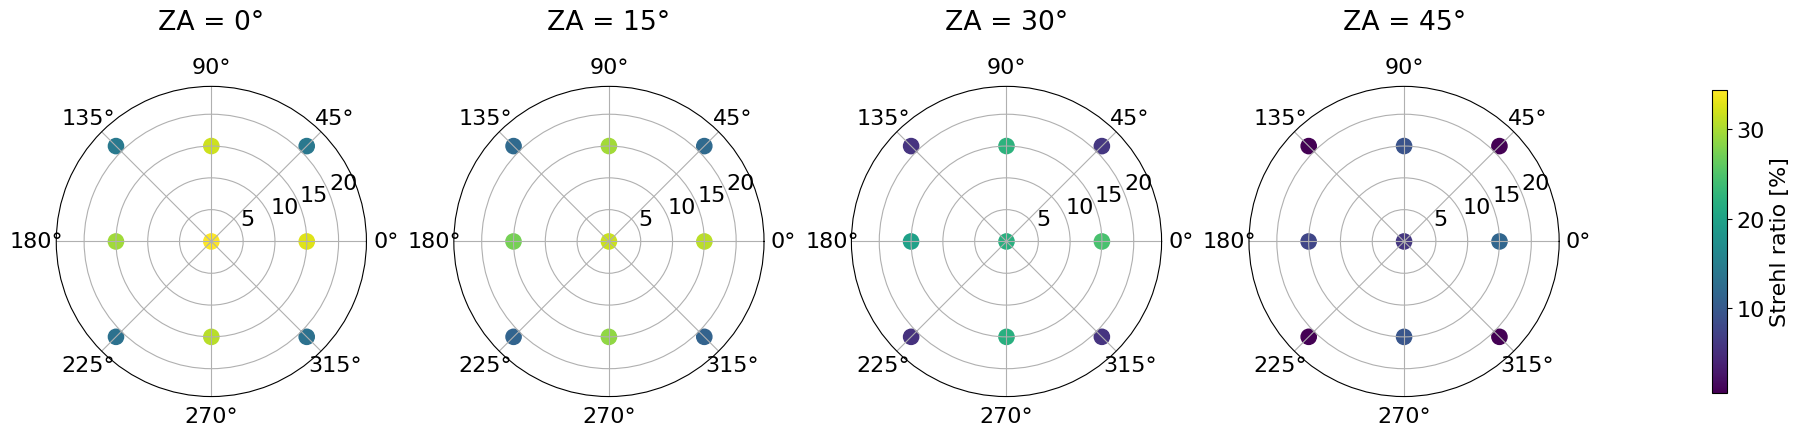

In [18]:
# Science-source positions from the MAVIS configuration
science_zenith = np.asarray(sim.my_data_map["sources_science"]["Zenith"], dtype=float)
science_azimuth = np.asarray(sim.my_data_map["sources_science"]["Azimuth"], dtype=float)

# Convert azimuth to radians for the polar plot
theta = np.deg2rad(science_azimuth)
# Use a common SR scale for all zenith-angle maps
all_sr = 100 * np.concatenate([np.asarray(r["sr"]) for r in zenith_results])

vmin = np.min(all_sr)
vmax = np.max(all_sr)
fig, axes = plt.subplots(1, len(zenith_results), figsize=(18, 4.5), subplot_kw={"projection": "polar"}, constrained_layout=True)
for ax, result in zip(axes, zenith_results):
    sr = 100 * np.asarray(result["sr"])
    # Plot the science directions, coloured by Strehl ratio
    sc = ax.scatter(theta, science_zenith, c=sr, s=120, vmin=vmin, vmax=vmax, cmap="viridis")
    # Keep the same field scale for all panels
    ax.set_ylim(0, np.max(science_zenith) * 1.15)
    # Match the TipTop field convention
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_title(f"ZA = {result['za']}°", pad=20)

# Common colour bar for all maps
cbar = fig.colorbar(sc, ax=axes, shrink=0.75, pad=0.08)
cbar.set_label("Strehl ratio [%]")
plt.show()

### I) Explore another parameter

The same in-memory workflow can be applied to any parameter available in the TipTop configuration.

Choose a parameter you would like to modify, define a range of values, rerun the simulation, and visualize the resulting PSFs or performance metrics.

You can inspect `sim.my_data_map` to identify the parameters available in the current MAVIS configuration.


In [ ]:
# Inspect the current TipTop configuration
sim.my_data_map.keys()
# Example, inspect the atmosphere:
print("\nAtmosphere:")
print(sim.my_data_map["atmosphere"])

# TODO:
parameter_values = [...]
my_results = []

for value in parameter_values:

    # Same starting point for every experiment
    sim.my_data_map = copy.deepcopy(base_config)

    # TODO 1 — change ONE parameter
    # Example for seeing:
    # sim.my_data_map["atmosphere"]["Seeing"] = float(value)

    sim.doOverallSimulation()
    sim.computeMetrics()

    # TODO 2 — save the quantity that answers YOUR question
    # my_results.append(...)

# TODO 3 — make ONE figure
#
# Your conclusion:
# "Changing ______ from ______ to ______ causes ______."

### J) Bonus — AO error breakdown

TipTop can also expose the individual terms of the AO error budget.

To inspect them, run the simulation with `verbose=True` and `getHoErrorBreakDown=True` to examine how the different error terms are affected when changing a parameter such as seeing or NGS flux.

In [ ]:
# Enable the detailed outputs required for the error breakdown
sim.verbose = True
sim.getHoErrorBreakDown = True

sim.doOverallSimulation()
sim.computeMetrics()